# Entraînement Semi-Supervisé (SSL) et Pseudo-Labeling

Ce notebook présente la phase finale et la plus critique du projet : la distinction entre cerveaux **Sains** (Normal) et **Cancéreux** (Cancer). 

**La problématique :**
Nous n'avons que 100 images labélisées par des experts. C'est trop peu pour entraîner un modèle de Deep Learning robuste à partir de zéro.

**La solution : Le Semi-Supervised Learning (SSL)**
1.  **Phase Supervisée** : Entraîner un modèle sur nos 100 images "vérité terrain".
2.  **Phase d'Inférence** : Utiliser ce modèle pour prédire la pathologie sur les 1400 images inconnues.
3.  **Pseudo-Labeling** : Sélectionner uniquement les prédictions dont le modèle est "sûr à 95%" pour créer de nouvelles étiquettes (pseudo-labels).
4.  **Affinement (Fine-tuning)** : Ré-entraîner le modèle sur le mélange d'images réelles et d'images pseudo-labélisées.

---
## 1. Configuration de l'environnement

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import numpy as np

# Import de PyTorch (Framework de Deep Learning)
import torch
import torch.nn as nn
from torchvision import models, transforms

# Configuration du chemin système pour accéder au module config
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from config.config import *

# Sélection de l'appareil de calcul : GPU (cuda) si disponible, sinon CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Le modèle s'exécutera sur : {device}")

Le modèle s'exécutera sur : cuda


## 2. Préparation des Données Supervisées
Nous nous concentrons d'abord sur les images dont nous connaissons l'orientation et le type (Normal/Cancer). Pour maximiser les chances de réussite, nous allons travailler uniquement sur les images vues du haut (**Top / Axial**), car c'est la vue la plus représentée.

**Nous allons établir la stragtégie suivante :**
Sur la base de la clusterisation des photos par orientation, nous allons utiliser la pseudo labelisation pour les images orientées top, car nous avons assez de 'normales' et de 'cancéreuses'.

### 2.1 Chargement et filtrage (Focus sur la vue 'TOP')

In [2]:
# récupération des images clusterisées par orientation
df_images = pd.read_parquet(image_orientation)
df_images.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
0,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,"[0.40974900126457214, 0.8732983469963074, 0.17...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,side,cancer,0,side
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top


### 2.2 Analyse du Bruit de Clustering (HDBSCAN)
L'algorithme HDBSCAN (utilisé dans le notebook précédent) identifie des images qui ne "ressemblent" techniquement à aucune des trois orientations majeures. Nous allons visualiser ces outliers et les exclure pour assainir le dataset.

In [3]:
# 1. Identification des outliers (Label -1 fourni par le clustering HDBSCAN)
df_hdbscan_noise = df_images[df_images['cluster_label'] == -1]

print(f"Nombre d'outliers structurels détectés par HDBSCAN : {len(df_hdbscan_noise)}")

# 2. Visualisation d'un échantillon de bruit
if len(df_hdbscan_noise) > 0:
    n_show = min(len(df_hdbscan_noise), 5)
    fig, axes = plt.subplots(1, n_show, figsize=(15, 5))
    if n_show == 1: axes = [axes]
    
    for i, (_, row) in enumerate(df_hdbscan_noise.head(n_show).iterrows()):
        # On tente de trouver l'image soit via son path enregistré, soit dans le dossier sans_label
        img_path = Path(row['path']) if pd.notna(row.get('path')) else BASE_DIR / "mri_dataset_brain_cancer_oc" / "sans_label" / row['name']
        if img_path.exists():
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"Outlier\n{row['name'][:10]}...", fontsize=8)
        axes[i].axis('off')
    plt.suptitle("Échantillon d'images rejetées par HDBSCAN (Bruit)")
    plt.show()

# 3. FILTRAGE ACTIF : On ne garde que les points appartenant à des clusters cohérents
df_images = df_images[df_images['cluster_label'] != -1].copy()
print(f"✅ Dataset global assaini : {len(df_images)} images restantes.")

Nombre d'outliers structurels détectés par HDBSCAN : 0
✅ Dataset global assaini : 1506 images restantes.


In [4]:
# dataframe des images 'TOP' cancéreuses
df_images_cancer_top= df_images[(df_images['orientation'] == 'top') & (df_images['type'] == 'cancer')]
df_images_cancer_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
1,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
2,0f718241-8f63-4b55-81ce-315324b51069.jpg,"[1.192965030670166, 1.1314507722854614, 0.1077...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
3,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,"[0.4946941137313843, 0.4560645818710327, 0.174...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
4,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,"[0.4919051229953766, 0.35454875230789185, 0.39...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top
9,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,"[0.8727291822433472, 0.7392463088035583, 0.012...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,cancer,2,top


In [5]:
# dataframe des images 'TOP' normales
df_images_normal_top= df_images[(df_images['orientation'] == 'top') & (df_images['type'] == 'normal')]
df_images_normal_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
50,0161f9bf-fa93-4d02-8dce-84bfd49fe6a2.jpg,"[0.666938304901123, 0.8587964177131653, 0.0786...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
51,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,"[0.27638107538223267, 1.021559715270996, 0.096...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
52,11825cf3-9b35-42d3-ac99-21f26dd2f94e.jpg,"[0.24565695226192474, 0.7865098714828491, 0.11...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
53,14703976-0467-4acb-ade4-8a375ebfd4f9.jpg,"[0.6598442196846008, 0.12885765731334686, 0.61...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top
54,1953e998-29b8-4d36-975f-007c4fcb84a3.jpg,"[0.19154807925224304, 0.3241497278213501, 0.31...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,2,top


In [6]:
# dataframe images 'TOP' non labelisées
df_images_unknown_top = df_images[(df_images['weak_orientation'] == 'top') & (df_images['type'] == 'unknown')]
df_images_unknown_top.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
101,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,"[0.36736008524894714, 0.7256330251693726, 0.49...",NaN,unknown,unknown,2,top
102,00455a62-f79f-4072-9a23-4951e759acdc.jpg,"[0.4033546447753906, 0.5182491540908813, 0.215...",NaN,unknown,unknown,2,top
103,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,"[0.3427850902080536, 0.9386187195777893, 0.403...",NaN,unknown,unknown,2,top
106,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,"[0.39659130573272705, 0.6688651442527771, 0.39...",NaN,unknown,unknown,2,top
110,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,"[0.9405089616775513, 1.1057313680648804, 0.056...",NaN,unknown,unknown,2,top


In [7]:
# dataframe entrainement image cancers et normales
df = pd.concat([df_images_cancer_top,df_images_normal_top],ignore_index=True)
df.describe(include='all')

,name,features,path,orientation,type,cluster_label,weak_orientation
count,69,69,69,69,69,69.0,69
unique,69,69,69,1,2,NaN,1
top,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,"[0.6502299308776855, 0.721211314201355, 0.0541...",C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,top,normal,NaN,top
freq,1,1,1,69,48,NaN,69
mean,NaN,NaN,NaN,NaN,NaN,2.0,NaN
std,NaN,NaN,NaN,NaN,NaN,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,2.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,2.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,2.0,NaN


In [8]:
# En Deep Learning, les labels doivent être numériques.
# 0 = Normal (Sain)
# 1 = Cancer (Pathologique)
df['type'] = df['type'].map({'cancer': 1, 'normal' : 0})

# On ne garde que les informations essentielles pour le chargement des images
df = df[['name', 'path', 'type']]
df.head()

,name,path,type
0,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
1,0f718241-8f63-4b55-81ce-315324b51069.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
2,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
3,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1
4,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1


### 2.3 Nettoyage Technique et Traitement des Outliers

Pour garantir la robustesse du modèle et répondre aux exigences de qualité des données, nous effectuons les nettoyages suivants :
1.  **Suppression du Bruit de Clustering** : Retirer les images marquées -1 par HDBSCAN.
2.  **Filtrage Technique** : Détecter et supprimer les images corrompues ou "vides" (fonds noirs sans signal anatomique).
3.  **Gestion des Valeurs Manquantes** : S'assurer que chaque entrée possède un fichier image valide.

In [ ]:
# Analyse de "santé" des images pour détecter les fichiers vides ou aberrants
def check_image_health(path):
    """Calcule la moyenne des pixels pour détecter les images 'vides' ou corrompues."""
    try:
        with Image.open(path) as img:
            # Convertit en niveaux de gris pour simplifier le calcul de moyenne
            img_array = np.array(img.convert('L'))
            return img_array.mean()
    except Exception:
        # Si le fichier ne peut pas être ouvert (corrompu)
        return -1 

# 1. Calcul de l'intensité moyenne pour les images supervisées
# Note : df est déjà issu de df_images qui a été filtré pour HDBSCAN ci-dessus
df['pixel_mean'] = df['path'].apply(check_image_health)

# 2. Filtrage des outliers d'intensité (fonds noirs / images blanches)
df_clean = df[df['pixel_mean'] > 10].copy()

print(f"--- Rapport de Nettoyage Technique ---")
print(f"✅ Images supervisées valides : {len(df_clean)} / {len(df)}")
print(f"📦 Images supprimées car 'vides' ou corrompues : {len(df) - len(df_clean)}")

# Mise à jour du DataFrame supervisé principal
df = df_clean.drop(columns=['pixel_mean'])

--- Rapport de Nettoyage Technique ---
✅ Images supervisées valides : 69 / 69
📦 Images supprimées car 'vides' ou corrompues : 0


In [14]:
# Visualisation des images supervisées rejetées (outliers techniques)
if (len(df) - len(df_clean)) != 0 :
    df_rejected_vis = df[df['pixel_mean'] <= 10].head(10)

    if len(df_rejected_vis) > 0:
        n_show = len(df_rejected_vis)
        fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
        if n_show == 1: axes = [axes]
        
        for i, (_, row) in enumerate(df_rejected_vis.iterrows()):
            img = Image.open(row['path'])
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f"Mean: {row['pixel_mean']:.1f}", fontsize=8)
            axes[i].axis('off')
        plt.suptitle("Échantillon d'images supervisées REJETÉES (Trop sombres/vides)")
        plt.show()
    else:
        print("Aucune image supervisée rejetée par le filtre d'intensité.")

## 3. Modélisation et Entraînement Supervisé
Pour que PyTorch puisse ingérer nos images efficacement, nous devons d'abord préparer le pipeline de données (Dataset/DataLoader), définir l'architecture de notre réseau de neurones, puis lancer l'entraînement de référence (Baseline).

In [15]:
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    stratify=df["type"],
    random_state=42
)
 

### 3.1 Création du Dataset et des DataLoaders
Le Dataset fait le pont entre notre DataFrame et les fichiers images. Les DataLoaders gèrent le découpage en "batches" pour le calcul sur GPU.

In [16]:
from torch.utils.data import Dataset
from PIL import Image

class BrainMRIDataset(Dataset):
    """
    Objet Dataset personnalisé qui :
    1. Lit le chemin de l'image
    2. Ouvre l'image avec PIL
    3. Applique les transformations (Resize, Normalize)
    4. Renvoie le couple (Image_Tensor, Label)
    """
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # Indispensable pour que PyTorch sache combien d'images traiter
        return len(self.df)

    def __getitem__(self, idx):
        # Récupéré par PyTorch à chaque itération
        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "type"]

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, label

In [17]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [18]:
from torch.utils.data import DataLoader

# Création des objets Dataset
train_dataset = BrainMRIDataset(df_train, train_transform)
val_dataset   = BrainMRIDataset(df_val, train_transform)

# Le DataLoader regroupe les images par "Batches" (paquets)
# Cela permet d'optimiser le calcul parallèle (GPU)
# shuffle=True remélange les images à chaque epoch pour éviter que le modèle n'apprenne l'ordre
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Batches d'entraînement : {len(train_loader)}")
print(f"Batches de validation : {len(val_loader)}")

Batches d'entraînement : 7
Batches de validation : 2


### 3.2 Architecture du Modèle (ResNet-50)
Nous utilisons une architecture ResNet-50 pré-entraînée (Transfer Learning) pour extraire les caractéristiques visuelles, en remplaçant uniquement la couche finale pour notre classification binaire (Sain/Cancer).

In [19]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Chargement de l'architecture ResNet50 pré-entraînée
model = models.resnet50(pretrained=True)

# 2. Transfer Learning (Gèle)
# On ne veut pas modifier les filtres qui reconnaissent les formes de base.
for param in model.parameters():
    param.requires_grad = False

# 3. Adaptation de la "tête" de classification
# ResNet50 finit normalement par 1000 classes.
# On la remplace par une couche linéaire qui sort 2 classes (Sain vs Cancer).
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device) # Transfert du modèle vers le GPU/CPU

# 4. Définition de la fonction de perte (Loss)
# CrossEntropyLoss est idéale pour la classification multi-classes (ici 2)
criterion = nn.CrossEntropyLoss()

# 5. Optimiseur (AdamW)
# On ne demande à l'optimiseur de mettre à jour QUE les paramètres de model.fc
optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Fabien\Desktop\OC\P10\BrainScanAI\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
def train_one_epoch(model, loader):
    model.train() # Mode entraînement (active dropout/batchnorm)
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Réinitialise les gradients (important avant chaque calcul)
        optimizer.zero_grad()

        # Phase Forward : calcule la prédiction
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Phase Backward : calcule le gradient (l'erreur à corriger)
        loss.backward()
        
        # Mise à jour des poids du modèle
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [21]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return {
        "loss": total_loss / len(loader),
        "f1": f1_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred)
    }

### 3.3 Entraînement et Visualisation des Performances
Nous lançons l'entraînement sur 15 époques. Les courbes de perte (Loss) et le score F1 nous permettront de juger de la pertinence de cette baseline supervisée.

In [22]:
epochs = 15
f1_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, val_loader)
    
    train_loss_history.append(train_loss)
    val_loss_history.append(metrics['loss'])
    f1_history.append(metrics['f1'])
    
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {metrics['loss']:.4f} | "
        f"F1: {metrics['f1']:.3f} | "
        f"Acc: {metrics['accuracy']:.3f}"
    )

Epoch 1/15 | Train Loss: 0.5914 | Val Loss: 0.4422 | F1: 0.000 | Acc: 0.714
Epoch 2/15 | Train Loss: 0.4422 | Val Loss: 0.3103 | F1: 0.667 | Acc: 0.857
Epoch 3/15 | Train Loss: 0.2965 | Val Loss: 0.2443 | F1: 0.857 | Acc: 0.929
Epoch 4/15 | Train Loss: 0.2598 | Val Loss: 0.2112 | F1: 0.857 | Acc: 0.929
Epoch 5/15 | Train Loss: 0.2400 | Val Loss: 0.1503 | F1: 1.000 | Acc: 1.000
Epoch 6/15 | Train Loss: 0.2329 | Val Loss: 0.1302 | F1: 1.000 | Acc: 1.000
Epoch 7/15 | Train Loss: 0.2098 | Val Loss: 0.1223 | F1: 1.000 | Acc: 1.000
Epoch 8/15 | Train Loss: 0.1745 | Val Loss: 0.1046 | F1: 1.000 | Acc: 1.000
Epoch 9/15 | Train Loss: 0.1467 | Val Loss: 0.1406 | F1: 1.000 | Acc: 1.000
Epoch 10/15 | Train Loss: 0.1198 | Val Loss: 0.0896 | F1: 1.000 | Acc: 1.000
Epoch 11/15 | Train Loss: 0.1265 | Val Loss: 0.1066 | F1: 1.000 | Acc: 1.000
Epoch 12/15 | Train Loss: 0.0671 | Val Loss: 0.1558 | F1: 1.000 | Acc: 1.000
Epoch 13/15 | Train Loss: 0.1089 | Val Loss: 0.0892 | F1: 1.000 | Acc: 1.000
Epoch 14

In [23]:
import numpy as np

np.mean(f1_history[-5:])


np.float64(1.0)

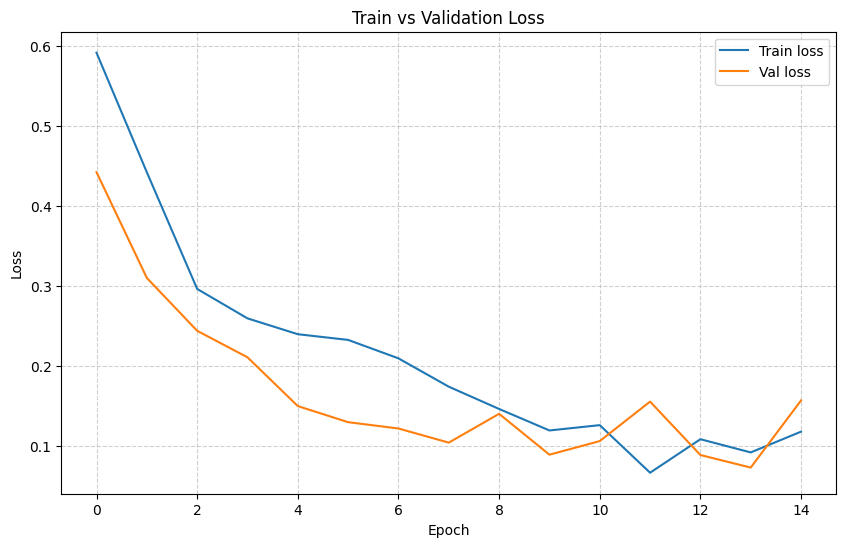

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Train loss")
plt.plot(val_loss_history, label="Val loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

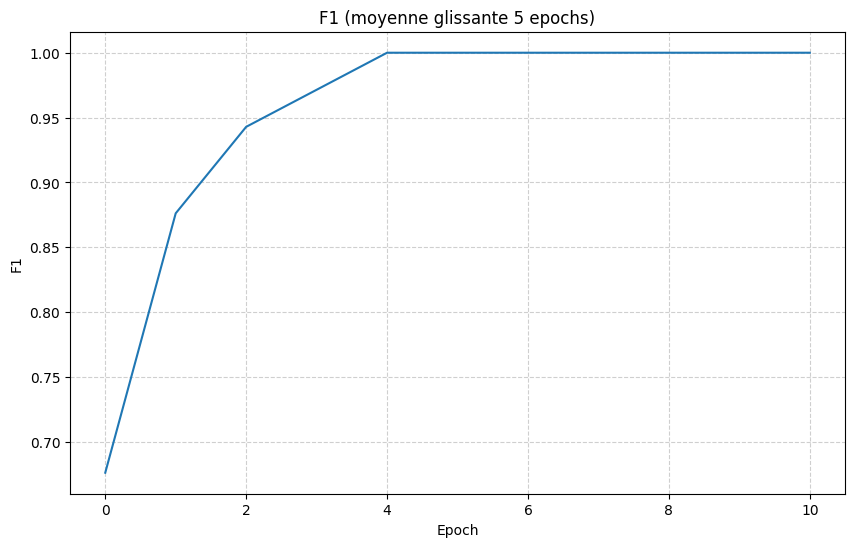

In [25]:
def moving_average(x, k=5):
    return np.convolve(x, np.ones(k)/k, mode="valid")

plt.figure(figsize=(10, 6))
plt.plot(moving_average(f1_history, 5))
plt.title("F1 (moyenne glissante 5 epochs)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Matrice de Confusion**
Visualisation des performances du modèle sur le jeu de validation.

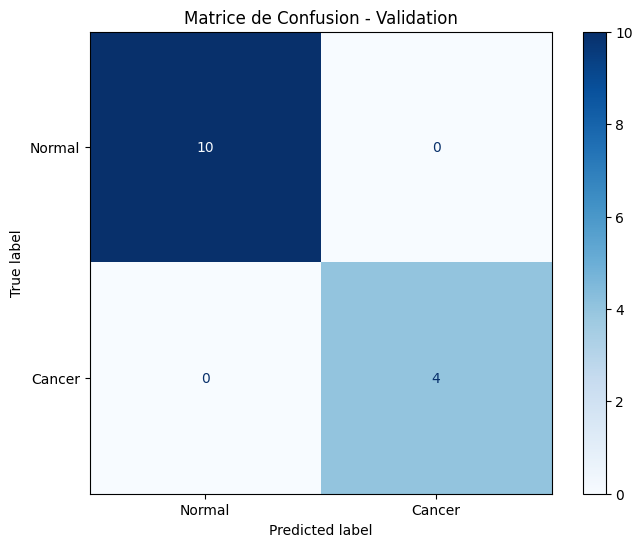

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Récupération des prédictions sur le jeu de validation
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Création de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Cancer']

# Affichage
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matrice de Confusion - Validation')
plt.show()

## 4. Phase Semi-Supervisée : Inférence et Pseudo-Labeling
Nous allons maintenant utiliser ce modèle "baseline" pour scanner nos 1400 images inconnues. Nous ne garderons que les images où le modèle est **très confiant** (Probabilité > 95% ou < 5%) pour créer notre nouveau jeu de données.

### 4.1 Récupération et Nettoyage des Données Non-Étiquetées
Avant de demander au modèle de prédire des labels, nous devons écarter les images de mauvaise qualité (images "écrasées", contrastes extrêmes ou fichiers corrompus) pour éviter de générer de faux pseudo-labels.

In [28]:
# 1. Chargement et filtrage initial des données non-étiquetées (Orientation TOP)
df_image_orientation = pd.read_parquet(image_orientation)
df_image_orientation = df_image_orientation[
    (df_image_orientation['weak_orientation'] == 'top') & 
    (df_image_orientation['type'] == 'unknown')
].copy()

def get_extended_stats(path):
    """Calcule la moyenne et l'écart-type pour détecter les anomalies de contraste."""
    try:
        with Image.open(path) as img:
            img_array = np.array(img.convert('L'))
            return img_array.mean(), img_array.std()
    except:
        return -1, -1

# 2. Calcul des statistiques techniques
print("Calcul des statistiques de qualité...")
stats = [get_extended_stats(BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / name) 
         for name in tqdm(df_image_orientation['name'])]
df_image_orientation['mean'], df_image_orientation['std'] = zip(*stats)

# 3. Définition des filtres de qualité
mask_quality = (
    (df_image_orientation['mean'] > 10) & 
    (df_image_orientation['std'] > 5) & 
    (df_image_orientation['std'] < 80)
)

# On sépare les données propres des rejets pour analyse
df_rejected_unlabeled_full = df_image_orientation[~mask_quality].copy()
df_unlabeled_clean = df_image_orientation[mask_quality].copy()

print(f"\n--- Rapport de Nettoyage Dataset Non-Étiqueté ---")
print(f"📦 Images initiales : {len(df_image_orientation)}")
print(f"⚠️ Images rejetées (Qualité/Contraste) : {len(df_rejected_unlabeled_full)}")
print(f"✅ Images prêtes pour le Pseudo-Labeling : {len(df_unlabeled_clean)}")

# Mise à jour de la variable principale
df_image_orientation = df_unlabeled_clean.drop(columns=['mean', 'std'])

Calcul des statistiques de qualité...


100%|██████████| 768/768 [00:05<00:00, 143.60it/s]


--- Rapport de Nettoyage Dataset Non-Étiqueté ---
📦 Images initiales : 768
⚠️ Images rejetées (Qualité/Contraste) : 46
✅ Images prêtes pour le Pseudo-Labeling : 722


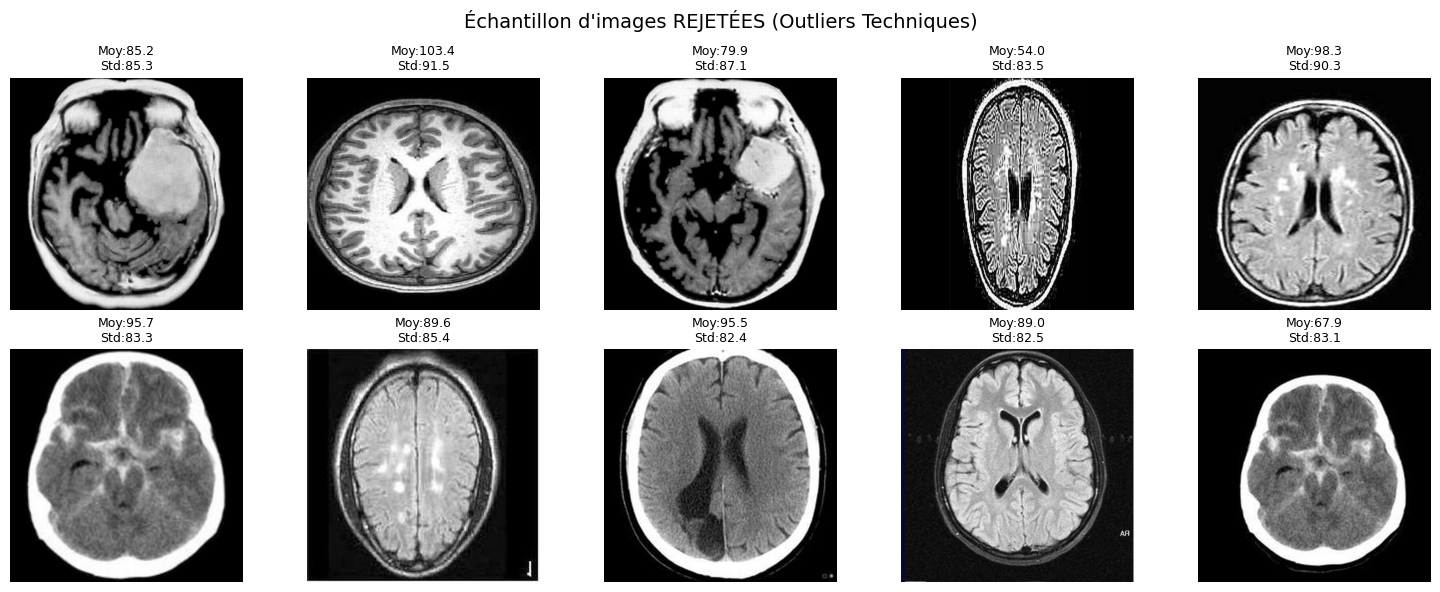

In [29]:
# Visualisation des 10 premières images REJETÉES
if len(df_rejected_unlabeled_full) > 0:
    n_show = min(len(df_rejected_unlabeled_full), 10)
    # Création d'une grille (2 lignes de 5 images)
    fig, axes = plt.subplots(int(np.ceil(n_show/5)), 5, figsize=(15, 3 * int(np.ceil(n_show/5))))
    axes = axes.flatten()
    
    for i in range(n_show):
        row = df_rejected_unlabeled_full.iloc[i]
        img_path = BASE_DIR / "mri_dataset_brain_cancer_oc" / "sans_label" / row['name']
        
        img = Image.open(img_path)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Moy:{row['mean']:.1f}\nStd:{row['std']:.1f}", fontsize=9)
        axes[i].axis('off')
    
    # Masquer les axes vides
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle("Échantillon d'images REJETÉES (Outliers Techniques)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune image n'a été rejetée par les filtres de qualité.")

In [30]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [31]:
# Cette cellule affichait précédemment le chargement. 
# Désormais, elle sert d'aperçu rapide du dataset prêt pour le pseudo-labeling.
print(f"Dataset prêt pour l'inférence : {df_image_orientation.shape}")
df_image_orientation.head()

Dataset prêt pour l'inférence : (722, 7)


,name,features,path,orientation,type,cluster_label,weak_orientation
101,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,"[0.36736008524894714, 0.7256330251693726, 0.49...",NaN,unknown,unknown,2,top
102,00455a62-f79f-4072-9a23-4951e759acdc.jpg,"[0.4033546447753906, 0.5182491540908813, 0.215...",NaN,unknown,unknown,2,top
103,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,"[0.3427850902080536, 0.9386187195777893, 0.403...",NaN,unknown,unknown,2,top
106,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,"[0.39659130573272705, 0.6688651442527771, 0.39...",NaN,unknown,unknown,2,top
110,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,"[0.9405089616775513, 1.1057313680648804, 0.056...",NaN,unknown,unknown,2,top


In [32]:
df_image_orientation.head()

,name,features,path,orientation,type,cluster_label,weak_orientation
101,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,"[0.36736008524894714, 0.7256330251693726, 0.49...",NaN,unknown,unknown,2,top
102,00455a62-f79f-4072-9a23-4951e759acdc.jpg,"[0.4033546447753906, 0.5182491540908813, 0.215...",NaN,unknown,unknown,2,top
103,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,"[0.3427850902080536, 0.9386187195777893, 0.403...",NaN,unknown,unknown,2,top
106,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,"[0.39659130573272705, 0.6688651442527771, 0.39...",NaN,unknown,unknown,2,top
110,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,"[0.9405089616775513, 1.1057313680648804, 0.056...",NaN,unknown,unknown,2,top


C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\00455a62-f79f-4072-9a23-4951e759acdc.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg
C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri_dataset_brain_cancer_oc\sans_label\01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg


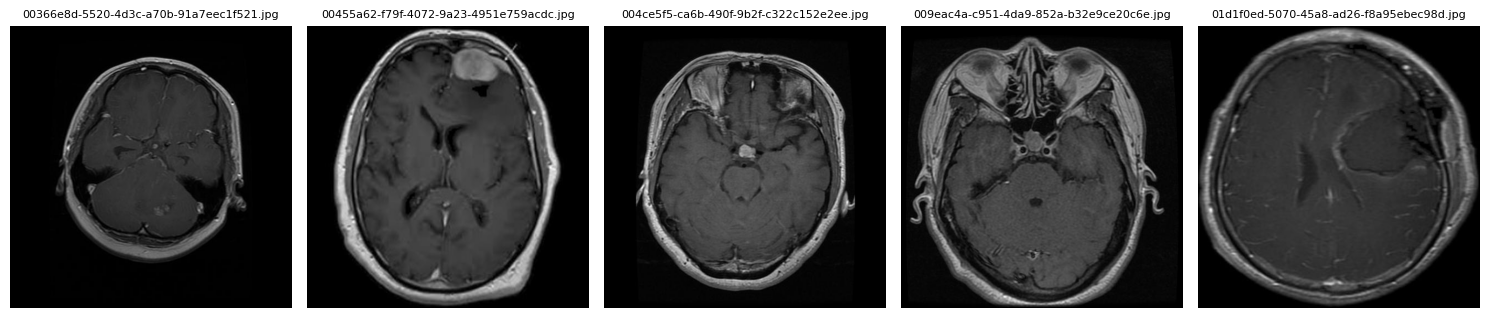

In [33]:
images_sans_label_dir = BASE_DIR / "mri_dataset_brain_cancer_oc" / "sans_label"

# Créer une grille 1x5
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
axes = axes.flatten()

n_display = min(len(df_image_orientation), len(axes))
for idx, img_name in enumerate(df_image_orientation['name'][:n_display]):
    img_path = images_sans_label_dir / img_name
    print(img_path)
    img = Image.open(img_path)
    axes[idx].imshow(img)  # Sans cmap='gray' pour afficher en couleur
    axes[idx].set_title(img_name, fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 4.2 Inférence : Génération des Scores de Probabilité
Le modèle parcourt l'ensemble des images "TOP" du dataset non-étiqueté pour estimer la probabilité de présence d'une tumeur.

In [34]:
model.eval() # Mode évaluation (très important pour l'inférence)
unlabeled = []

with torch.no_grad(): # Pas besoin de calcul de gradient ici
    for image_name in tqdm(df_image_orientation['name'], desc= 'Pseudo-labeling : '):
        img_path = BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / image_name
        img = Image.open(img_path).convert('RGB')
        
        # Ajout de la dimension batch (1, 3, 224, 224)
        x = transform(img).unsqueeze(0).to(device)

        # Calcul des scores (logits)
        logits = model(x)
        
        # Conversion des scores en Probabilités (0 à 1) via Softmax
        probs = torch.softmax(logits, dim=1)
        
        # On récupère la probabilité d'être de la classe 1 (Cancer)
        prob_cancer = probs[0, 1].item() 

        unlabeled.append({
            'name' : image_name,
            'prob_cancer' : prob_cancer
        })
        
df_unlabeled = pd.DataFrame(unlabeled)

Pseudo-labeling : 100%|██████████| 722/722 [00:25<00:00, 28.34it/s]


### 4.3 Sélection des Pseudo-Labels (Seuils de Confiance)
Nous ne conservons que les prédictions extrêmes (très probables ou très improbables). Ces images deviennent nos "Pseudo-Labels" pour la phase d'affinement.

In [35]:
TH_HIGH = 0.95
TH_LOW = 0.05

df_pseudo = df_unlabeled[
    (df_unlabeled["prob_cancer"] >= TH_HIGH) |
    (df_unlabeled["prob_cancer"] <= TH_LOW)
].copy()

# Attribution du label en fonction de la probabilité
df_pseudo['type'] = df_pseudo['prob_cancer'].apply(lambda x: 1 if x >= TH_HIGH else 0)

df_pseudo['path'] = df_pseudo.apply(lambda row : str(BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / row['name']),axis=1)

df_pseudo ['origin'] = 'pseudo_labeled'
print(f"Nombre d'images retenues pour le pseudo-labeling : {len(df_pseudo)} / {len(df_unlabeled)}")
print("Répartition des pseudo-labels :")
print(df_pseudo['type'].value_counts())

df_pseudo.head()

Nombre d'images retenues pour le pseudo-labeling : 293 / 722
Répartition des pseudo-labels :
type
1    242
0     51
Name: count, dtype: int64


,name,prob_cancer,type,path,origin
0,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,0.997740,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
2,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,0.979130,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
3,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,0.984181,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
4,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,0.966900,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
5,0208c07c-bc4b-4741-ad0f-d5beeb18cc52.jpg,0.989860,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled


In [36]:
sample_positive_test = df_pseudo[df_pseudo['type']==1][:5]
sample_positive_test

,name,prob_cancer,type,path,origin
0,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,0.997740,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
2,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,0.979130,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
3,009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg,0.984181,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
4,01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg,0.966900,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled
5,0208c07c-bc4b-4741-ad0f-d5beeb18cc52.jpg,0.989860,1,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,pseudo_labeled


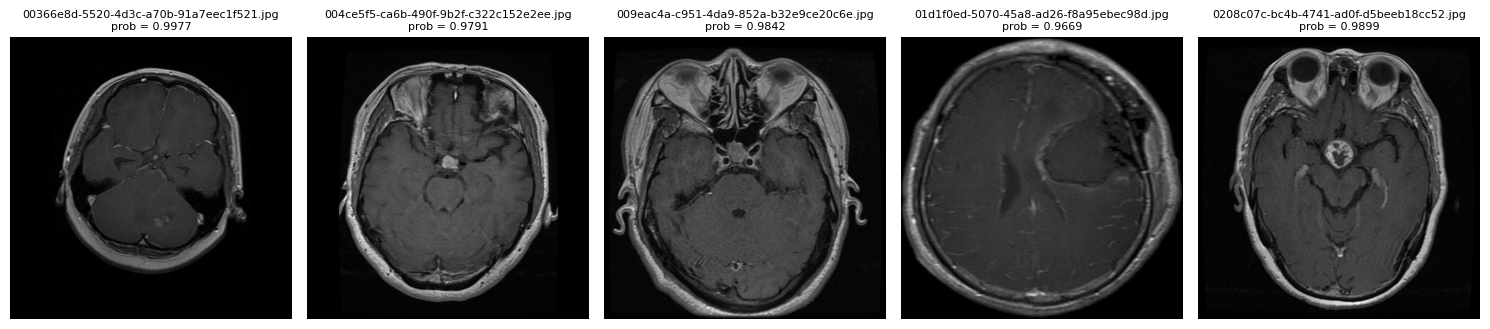

In [37]:
# On limite à 5 images pour correspondre à la grille 1x5
n_display = min(len(sample_positive_test), 5)

if n_display == 0:
    print("Aucune image positive trouvée.")
else:
    fig, axes = plt.subplots(1, n_display, figsize=(15, 6))
    
    # Gestion du cas où il n'y a qu'une seule image (axes n'est pas une liste)
    if n_display == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Utilisation de iterrows() pour accéder aux données proprement (évite les erreurs d'index .loc)
    for idx, (original_idx, row) in enumerate(sample_positive_test.head(n_display).iterrows()):
        img_name = row['name']
        prob = row['prob_cancer']
        img_path = images_sans_label_dir / img_name
        
        img = Image.open(img_path)
        axes[idx].imshow(img)
        # Utilisation de doubles quotes pour l'f-string et affichage de la probabilité formatée
        axes[idx].set_title(f"{img_name}\nprob = {prob:.4f}", fontsize=8)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

## 5. Affinement du Modèle : Fine-Tuning Final
Nous fusionnons maintenant nos images réelles avec nos centaines de "Pseudo-Labels" pour ré-entraîner le modèle sur un dataset beaucoup plus large, ce qui devrait améliorer sa capacité de généralisation.

In [38]:
df.head()
df.shape

(69, 3)

In [39]:
df_pseudo.drop(columns=['prob_cancer'],inplace=True)
df_pseudo.head()
df_pseudo.shape

(293, 4)

In [40]:

df['origin'] = 'labeled'
df_merged = pd.concat([df,df_pseudo])

df_merged.shape

(362, 4)

In [41]:
df_merged.head(
)

,name,path,type,origin
0,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1,labeled
1,0f718241-8f63-4b55-81ce-315324b51069.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1,labeled
2,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1,labeled
3,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1,labeled
4,3c3d07cb-ec2a-43b0-b8a3-3a51573ad930.jpg,C:\Users\Fabien\Desktop\OC\P10\BrainScanAI\mri...,1,labeled


In [42]:
df_merged["type"].value_counts()

type
1    263
0     99
Name: count, dtype: int64

### 5.1 Entraînement sur Dataset Mixte (Vrais + Pseudo Labels)
Nous conservons le même jeu de validation (uniquement composé de vraies étiquettes) pour évaluer la progression réelle du modèle.

In [43]:
# On regroupe les vrais labels d'entrainement et les pseudo-labels
# On utilise df_train qui a été défini lors du premier split (cellule 14)
df_train_mixed = pd.concat([df_train, df_pseudo], ignore_index=True)

# On garde le df_val initial (qui ne contient que des vrais labels) pour la validation
# Cela permet une comparaison honnête des performances
train_dataset = BrainMRIDataset(df_train_mixed, train_transform)
val_dataset   = BrainMRIDataset(df_val, train_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Entrainement sur {len(df_train_mixed)} images ({len(df_pseudo)} pseudo-labels)")
print(f"Validation sur {len(df_val)} vraies images")

epochs = 15
f1_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, val_loader)
    
    train_loss_history.append(train_loss)
    val_loss_history.append(metrics['loss'])
    f1_history.append(metrics['f1'])
    
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {metrics['loss']:.4f} | "
        f"F1: {metrics['f1']:.3f} | "
        f"Acc: {metrics['accuracy']:.3f}"
    )

Entrainement sur 348 images (293 pseudo-labels)
Validation sur 14 vraies images
Epoch 1/15 | Train Loss: 0.2036 | Val Loss: 0.0725 | F1: 1.000 | Acc: 1.000
Epoch 2/15 | Train Loss: 0.0436 | Val Loss: 0.1059 | F1: 1.000 | Acc: 1.000
Epoch 3/15 | Train Loss: 0.0640 | Val Loss: 0.1072 | F1: 1.000 | Acc: 1.000
Epoch 4/15 | Train Loss: 0.0764 | Val Loss: 0.0677 | F1: 1.000 | Acc: 1.000
Epoch 5/15 | Train Loss: 0.0344 | Val Loss: 0.2910 | F1: 0.800 | Acc: 0.857
Epoch 6/15 | Train Loss: 0.0379 | Val Loss: 0.1085 | F1: 1.000 | Acc: 1.000
Epoch 7/15 | Train Loss: 0.0361 | Val Loss: 0.2361 | F1: 0.889 | Acc: 0.929
Epoch 8/15 | Train Loss: 0.0276 | Val Loss: 0.2038 | F1: 0.889 | Acc: 0.929
Epoch 9/15 | Train Loss: 0.0437 | Val Loss: 0.0726 | F1: 1.000 | Acc: 1.000
Epoch 10/15 | Train Loss: 0.0565 | Val Loss: 0.1498 | F1: 0.889 | Acc: 0.929
Epoch 11/15 | Train Loss: 0.0501 | Val Loss: 0.0627 | F1: 1.000 | Acc: 1.000
Epoch 12/15 | Train Loss: 0.0934 | Val Loss: 0.0663 | F1: 1.000 | Acc: 1.000
Epoch

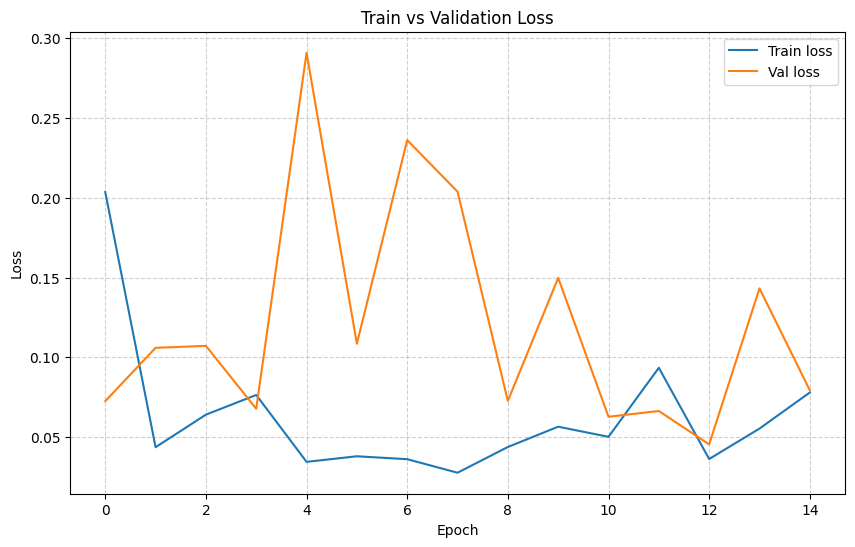

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label="Train loss")
plt.plot(val_loss_history, label="Val loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

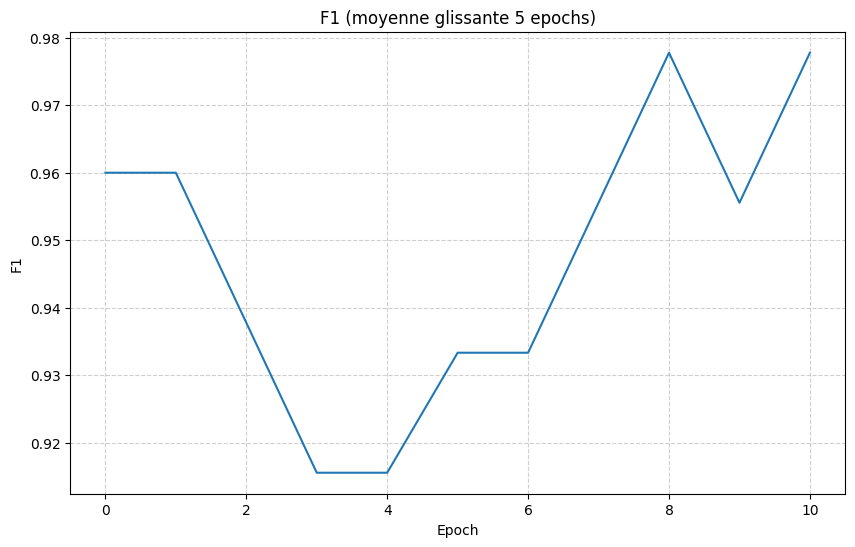

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(moving_average(f1_history, 5))
plt.title("F1 (moyenne glissante 5 epochs)")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

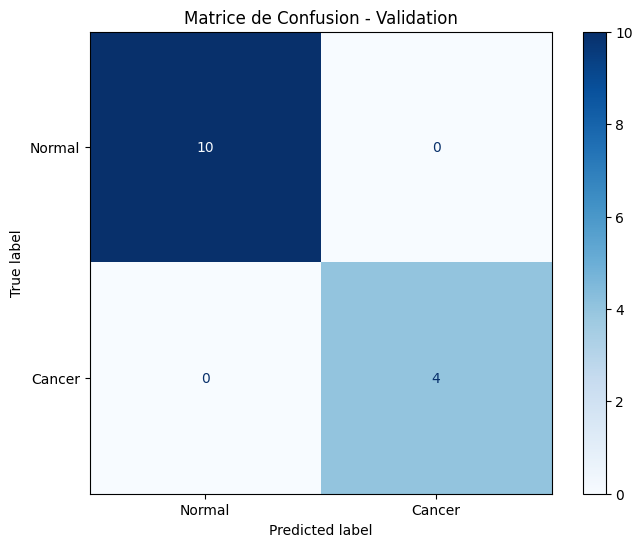

In [46]:

# Récupération des prédictions sur le jeu de validation
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Création de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Cancer']

# Affichage
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matrice de Confusion - Validation')
plt.show()

### 5.2 Seconde Passe de Pseudo-Labeling
Avec un modèle désormais plus robuste, nous tentons de labéliser les images qui étaient restées dans la "zone d'incertitude" lors de la première passe.

In [47]:
# 1. Identifier les images restantes (non encore pseudo-labelisées)
pseudo_names = set(df_pseudo['name'])
df_remaining = df_unlabeled[~df_unlabeled['name'].isin(pseudo_names)].copy()

print(f"Images restant à traiter : {len(df_remaining)}")

# 2. Relancer l'inférence avec le modèle affiné
model.eval()
second_pass_results = []

with torch.no_grad():
    for image_name in tqdm(df_remaining['name'], desc='Seconde passe : '):
        img_path = BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / image_name
        img = Image.open(img_path).convert('RGB')
        x = transform(img).unsqueeze(0).to(device)
        
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        prob = probs[0, 1].item()
        
        second_pass_results.append({'name': image_name, 'prob_cancer': prob})

df_second_pass = pd.DataFrame(second_pass_results)

# 3. Appliquer les seuils de confiance
df_pseudo_v2 = df_second_pass[
    (df_second_pass["prob_cancer"] >= TH_HIGH) |
    (df_second_pass["prob_cancer"] <= TH_LOW)
].copy()

df_pseudo_v2['type'] = df_pseudo_v2['prob_cancer'].apply(lambda x: 1 if x >= TH_HIGH else 0)
df_pseudo_v2['path'] = df_pseudo_v2.apply(lambda row : str(BASE_DIR / 'mri_dataset_brain_cancer_oc' / 'sans_label' / row['name']), axis=1)
df_pseudo_v2['origin'] = 'pseudo_labeled_v2'

print(f"\nNouvelles images récupérées : {len(df_pseudo_v2)}")
print("Répartition des nouveaux labels :")
print(df_pseudo_v2['type'].value_counts())

# Optionnel : Fusionner avec le jeu global pour un éventuel 3ème entraînement
# df_final_mixed = pd.concat([df_train_mixed, df_pseudo_v2], ignore_index=True)

Images restant à traiter : 429


Seconde passe : 100%|██████████| 429/429 [00:14<00:00, 30.40it/s]


Nouvelles images récupérées : 254
Répartition des nouveaux labels :
type
1    165
0     89
Name: count, dtype: int64


## 6. Conclusion et Enseignements
Ce processus de "Self-Training" ou **Pseudo-Labeling** a permis de passer d'un échantillon médical très pauvre (100 images) à un dataset de recherche riche.

**Résultats clés :**
1.  **Stabilité** : La validation sur des images "vérité terrain" uniquement garantit un score F1 honnête.
2.  **Gains** : L'intégration des pseudo-labels aide le modèle à mieux généraliser les structures anatomiques complexes.
3.  **Seconde Passe** : La réitération du processus sur les images restantes (incertaines lors de la 1ère passe) permet de maximiser le taux d'utilisation du dataset brut.

👉 **Le modèle est maintenant prêt pour une phase de test final ou une intégration dans un outil de diagnostic.**